In [1]:
%pylab inline
import xarray as xr
import cmocean.cm as cmo
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import os
import gsw
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from sklearn.linear_model import HuberRegressor, LinearRegression

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
data_dir = '/Volumes/Nikita/PhD/Data/Gliders/Sunfish/SBUS/'

In [3]:
### load weather data
met_path = data_dir+'weather/wam_sunfish_weather.csv'
metdf = pd.read_csv(met_path)
metdf['Datetime'] = pd.to_datetime(metdf['TimeStamp']) ## fix date format

In [6]:
### load wave data
wave_path = data_dir+'waves/wam_sunfish_waves_data.csv'
wavdf = pd.read_csv(wave_path)
wavdf['Datetime'] = pd.to_datetime(wavdf['TimeStamp']) ## fix date format

In [8]:
## load vegas data files
ctd_files = sorted(glob.glob(os.path.join(data_dir , 'ctd/wam*.csv')))

if not ctd_files:
    raise FileNotFoundError("No wam*.csv files found in ../ctd/")
### concatenate data
ctdf = pd.concat(
    (pd.read_csv(f) for f in ctd_files),
    ignore_index=True
)

In [37]:
ctdf['Datetime'] = pd.to_datetime(ctdf['TimeStamp']) 
ctdf = ctdf.drop_duplicates(subset='Datetime', keep='first')

In [44]:
start = '2026-03-25'
end = '2026-05-01'
ctdf = ctdf[(ctdf['Datetime'] >= start) & (ctdf['Datetime'] <= end)]
ctdf = ctdf.sort_values('Datetime')

In [11]:
def dms_to_dd(arr):
    """
    Convert lon-lat from degrees minutes to decimal degrees
    """
    arr = np.array(arr, dtype=float)
    sign = np.sign(arr) ##  get sign (-/+)
    abs_arr = np.abs(arr) 
    degrees = np.floor(abs_arr / 100)
    minutes = abs_arr % 100
    dd = sign * (degrees + minutes / 60)
    return dd

In [12]:
## bathymentry
isobaths='/Volumes/Nikita/PhD/Data/Bathymetry/gebco.nc'
iso=xr.open_dataset(isobaths)
factor = 2
Iso = iso.coarsen(lon=factor, lat=factor).mean()
minimum = -1000
maximum = 0
mask = (Iso.elevation > minimum) & (Iso.elevation < maximum)

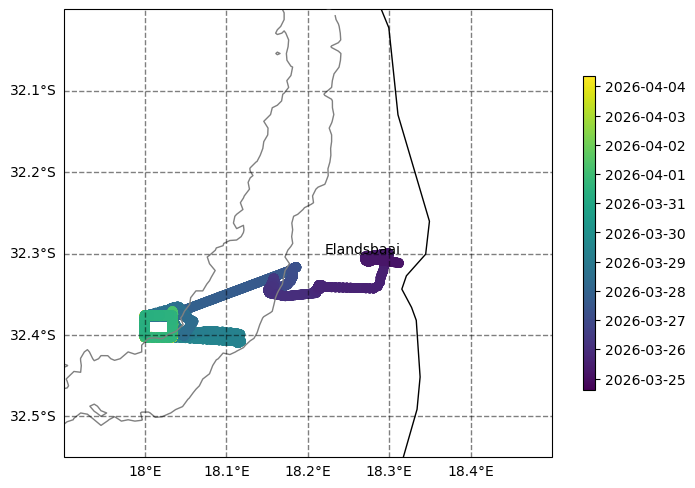

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.dates as mdates

fig = plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())



# Convert datetime to matplotlib numbers
time_num = mdates.date2num(ctdf['Datetime'])

sc = ax.scatter(ctdf["Longitude(deg)"],
    ctdf["Latitude(deg)"],
    c=time_num,
    transform=ccrs.PlateCarree()
)

# Proper colorbar formatting
cbar = plt.colorbar(sc, ax=ax, shrink=0.7, aspect=25, pad=0.05)

cbar.locator = mdates.AutoDateLocator()
cbar.formatter = mdates.DateFormatter('%Y-%m-%d')
cbar.update_ticks()

# Remove default ticks
ax.set_xticks([])
ax.set_yticks([])

# Map features
ax.coastlines()
ax.set_extent([17.9, 18.5, -32.55, -32])

# Contours
cs = ax.contour(
    Iso.lon, Iso.lat, Iso.elevation,
    levels=[-200,-150,-100,-80],
    colors='gray',
    linewidths=1,linestyles='-',
    transform=ccrs.PlateCarree()  # important for Cartopy
)

# List of (x, y) positions where you want labels
label_positions = [(17.2, -32.5), (17.8, -32.0), (18.0, -31.7),(18.2, -32)]

ax.clabel(
    cs,
    inline=True,
    fontsize=10,
    fmt='%d',
    manual=label_positions
)
gridlines = ax.gridlines(
    draw_labels=True,
    linewidth=1,
    color='k',
    alpha=0.5,
    linestyle='--'
)
gridlines.right_labels = False
gridlines.top_labels = False
gridlines.xlabel_style = {'size': 10}
gridlines.ylabel_style = {'size': 10}

#ax.text(18,-32.8,'Cape Town')
ax.text(18.22,-32.3,'Elandsbaai')

plt.tight_layout()
plt.savefig('/Volumes/Nikita/PhD/Figures/Sunfish/SBUS/surface_map.png')
plt.show()


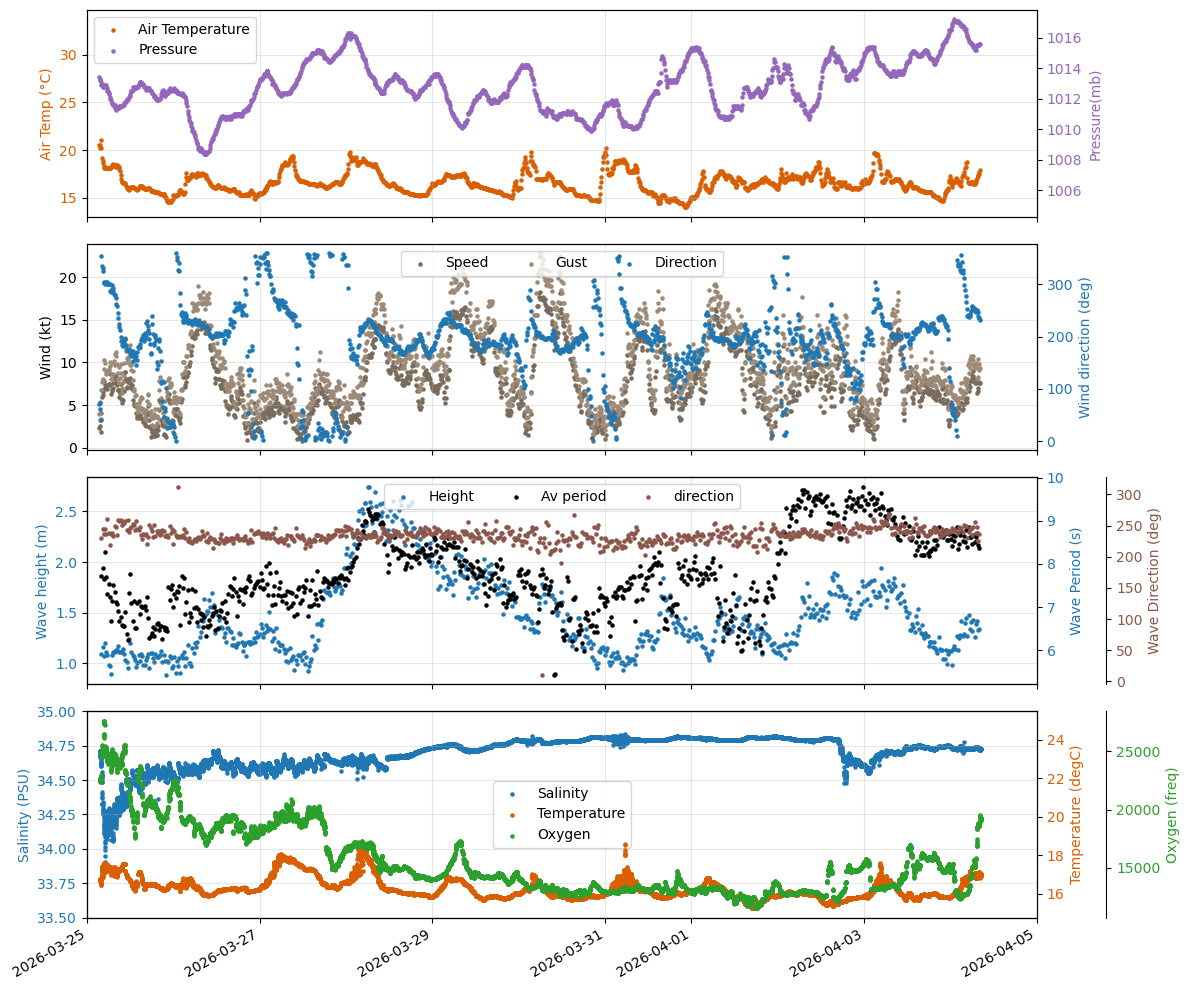

In [39]:
fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# ==========================================================
# 1) Air Temperature + Pressure
# ==========================================================
sc1 = ax[0].scatter(metdf['Datetime'],
                    metdf['Temperature(degC)'],
                    c='#D95F02', s=5)

ax[0].set_ylabel('Air Temp (°C)', color='#D95F02')
ax[0].tick_params(axis='y', labelcolor='#D95F02')

ax0_r = ax[0].twinx()
sc2 = ax0_r.scatter(metdf['Datetime'],
                    metdf['Pressure(mb)'],
                    c='tab:purple', s=5)

ax0_r.set_ylabel('Pressure(mb)', color='tab:purple')
ax0_r.tick_params(axis='y', labelcolor='tab:purple')

ax[0].legend([sc1, sc2], ['Air Temperature', 'Pressure'],
             loc='upper left', ncol=1)
ax[1].set_xlim(pd.to_datetime('2026-03-25'),pd.to_datetime('2026-04-05'))
# ==========================================================
# 2) Wind Speed + Gust (colored by direction)
# ==========================================================
sc1 = ax[1].scatter(metdf['Datetime'],
                    metdf['Wind Speed(kt)'],
                    c='#7A6C5D',
                    s=5)

sc2 = ax[1].scatter(metdf['Datetime'],
                    metdf['Wind Gust Speed(kt)'],
                    c= '#9C8A77',
                    s=5)

ax1_r = ax[1].twinx()
sc3 = ax1_r.scatter(metdf['Datetime'],
                    metdf['Wind Direction'],
                    c='#1F78B4', s=5)

ax1_r.set_ylabel('Wind direction (deg)', color='#1F78B4')
ax1_r.tick_params(axis='y', labelcolor='#1F78B4')


ax[1].set_ylabel('Wind (kt)')
ax[1].legend([sc1,sc2,sc3], ['Speed', 'Gust','Direction'],
             loc='upper center', ncol=3)

# ==========================================================
# 3) waves: height 
# ==========================================================
sc1 = ax[2].scatter(wavdf['Datetime'],
                    wavdf['Hs (m)'],
                    c='tab:blue', s=5)
ax[2].set_ylabel('Wave height (m)', color='tab:blue')
ax[2].tick_params(axis='y', labelcolor='tab:blue')

ax2_r1 = ax[2].twinx()
sc2 = ax2_r1.scatter(wavdf['Datetime'],
                    wavdf['Ta (s)'],
                    c='k', s=5)

#sc3 = ax2_r1.scatter(wavdf['Datetime'],wavdf['Tp (s)'],c='gray', s=5)
ax2_r1.set_ylabel('Wave Period (s)', color='tab:blue')
ax2_r1.tick_params(axis='y', labelcolor='tab:blue')


ax2_r2 = ax[2].twinx()
ax2_r2.spines['right'].set_position(('outward', 50))

sc4 = ax2_r2.scatter(wavdf['Datetime'],
                     wavdf['Dp (deg)'],
                     c='tab:brown', s=5)
ax2_r2.set_ylabel('Wave Direction (deg)', color='tab:brown')
ax2_r2.tick_params(axis='y', labelcolor='tab:brown')

ax[2].legend([sc1, sc2, sc4], ['Height', 'Av period', 'direction'],loc='upper center', ncol=3)

# ==========================================================
# 4) Salinity + Temp + Oxygen
# ==========================================================
sc1 = ax[3].scatter(ctdf['Datetime'],
                    ctdf['Salinity (PSU)'],
                    c='tab:blue', s=5)

ax[3].set_ylabel('Salinity (PSU)', color='tab:blue')
ax[3].tick_params(axis='y', labelcolor='tab:blue')

ax3_r1 = ax[3].twinx()
sc2 = ax3_r1.scatter(ctdf['Datetime'],
                     ctdf['Temperature (degC)'],
                     c='#D95F02', s=5)

ax3_r1.set_ylabel('Temperature (degC)', color='#D95F02')
ax3_r1.tick_params(axis='y', labelcolor='#D95F02')

ax3_r2 = ax[3].twinx()
ax3_r2.spines['right'].set_position(('outward', 50))

sc3 = ax3_r2.scatter(ctdf['Datetime'],
                     ctdf['Oxygen (freq)'],
                     c='tab:green', s=5)

ax3_r2.set_ylabel('Oxygen (freq)', color='tab:green')
ax3_r2.tick_params(axis='y', labelcolor='tab:green')

ax[3].legend([sc1, sc2, sc3],
             ['Salinity', 'Temperature', 'Oxygen'],
             loc='center', ncol=1)
ax[3].set_ylim(33.5,35)

# ==========================================================
for a in ax:
    a.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('/Volumes/Nikita/PhD/Figures/Sunfish/SBUS/wg_variables_scatter.png')
plt.show()


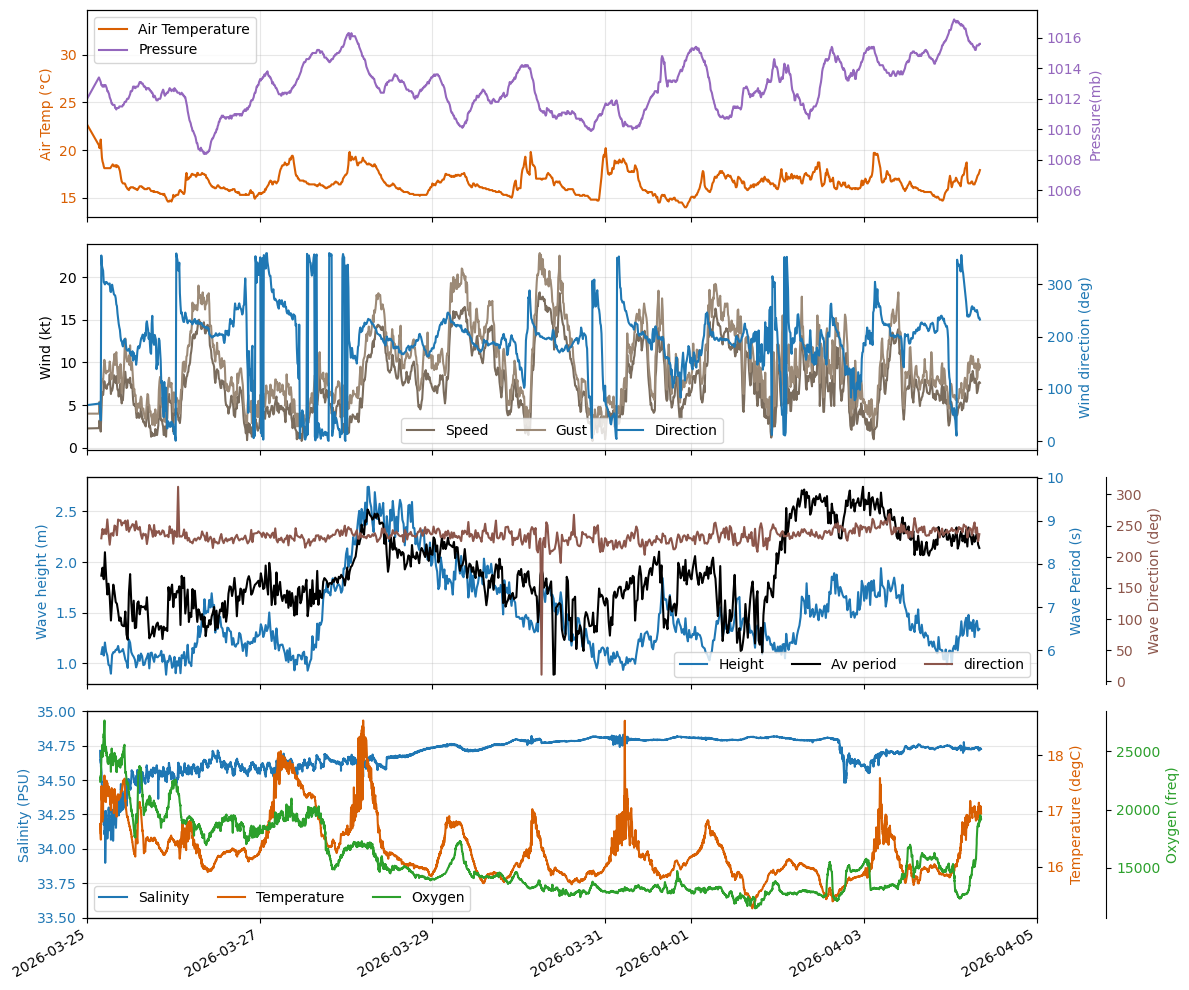

In [51]:
fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# ==========================================================
# 1) Air Temperature + Pressure
# ==========================================================
sc1 = ax[0].plot(metdf['Datetime'],
                    metdf['Temperature(degC)'],
                    c='#D95F02')

ax[0].set_ylabel('Air Temp (°C)', color='#D95F02')
ax[0].tick_params(axis='y', labelcolor='#D95F02')

ax0_r = ax[0].twinx()
sc2 = ax0_r.plot(metdf['Datetime'],
                    metdf['Pressure(mb)'],
                    c='tab:purple')

ax0_r.set_ylabel('Pressure(mb)', color='tab:purple')
ax0_r.tick_params(axis='y', labelcolor='tab:purple')

ax[0].legend([sc1[0], sc2[0]], ['Air Temperature', 'Pressure'],
             loc='upper left', ncol=1)
ax[1].set_xlim(pd.to_datetime('2026-03-25'),pd.to_datetime('2026-04-05'))
# ==========================================================
# 2) Wind Speed + Gust (colored by direction)
# ==========================================================
sc1 = ax[1].plot(metdf['Datetime'],
                    metdf['Wind Speed(kt)'],
                    c='#7A6C5D')

sc2 = ax[1].plot(metdf['Datetime'],
                    metdf['Wind Gust Speed(kt)'],
                    c= '#9C8A77')

ax1_r = ax[1].twinx()
sc3 = ax1_r.plot(metdf['Datetime'],
                    metdf['Wind Direction'],
                    c='#1F78B4')

ax1_r.set_ylabel('Wind direction (deg)', color='#1F78B4')
ax1_r.tick_params(axis='y', labelcolor='#1F78B4')


ax[1].set_ylabel('Wind (kt)')
ax[1].legend([sc1[0],sc2[0],sc3[0]], ['Speed', 'Gust','Direction'],
             loc='lower center', ncol=3)

# ==========================================================
# 3) waves: height 
# ==========================================================
sc1 = ax[2].plot(wavdf['Datetime'],
                    wavdf['Hs (m)'],
                    c='tab:blue')
ax[2].set_ylabel('Wave height (m)', color='tab:blue')
ax[2].tick_params(axis='y', labelcolor='tab:blue')

ax2_r1 = ax[2].twinx()
sc2 = ax2_r1.plot(wavdf['Datetime'],
                    wavdf['Ta (s)'],
                    c='k')

#sc3 = ax2_r1.scatter(wavdf['Datetime'],wavdf['Tp (s)'],c='gray', s=5)
ax2_r1.set_ylabel('Wave Period (s)', color='tab:blue')
ax2_r1.tick_params(axis='y', labelcolor='tab:blue')


ax2_r2 = ax[2].twinx()
ax2_r2.spines['right'].set_position(('outward', 50))

sc4 = ax2_r2.plot(wavdf['Datetime'],
                     wavdf['Dp (deg)'],
                     c='tab:brown')
ax2_r2.set_ylabel('Wave Direction (deg)', color='tab:brown')
ax2_r2.tick_params(axis='y', labelcolor='tab:brown')

ax[2].legend([sc1[0], sc2[0],sc4[0]], ['Height', 'Av period', 'direction'],loc='lower right', ncol=3)

# ==========================================================
# 4) Salinity + Temp + Oxygen
# ==========================================================
sc1 = ax[3].plot(ctdf['Datetime'],
                    ctdf['Salinity (PSU)'],
                    c='tab:blue')

ax[3].set_ylabel('Salinity (PSU)', color='tab:blue')
ax[3].tick_params(axis='y', labelcolor='tab:blue')

ax3_r1 = ax[3].twinx()
sc2 = ax3_r1.plot(ctdf['Datetime'],
                     ctdf['Temperature (degC)'],
                     c='#D95F02')

ax3_r1.set_ylabel('Temperature (degC)', color='#D95F02')
ax3_r1.tick_params(axis='y', labelcolor='#D95F02')

ax3_r2 = ax[3].twinx()
ax3_r2.spines['right'].set_position(('outward', 50))

sc3 = ax3_r2.plot(ctdf['Datetime'],
                     ctdf['Oxygen (freq)'],
                     c='tab:green')

ax3_r2.set_ylabel('Oxygen (freq)', color='tab:green')
ax3_r2.tick_params(axis='y', labelcolor='tab:green')

ax[3].legend([sc1[0], sc2[0], sc3[0]],
             ['Salinity', 'Temperature', 'Oxygen'],
             loc='lower left', ncol=3)
ax[3].set_ylim(33.5,35)

# ==========================================================
for a in ax:
    a.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('/Volumes/Nikita/PhD/Figures/Sunfish/SBUS/wg_variables_line.png')
plt.show()